In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "duckdb",
#     "matplotlib",
#     "numpy",
#     "pandas",
#     "polars",
#     "pyarrow",
#     "scikit-learn",
#     "seaborn",
# ]
#
# [tool.uv]
# exclude-newer = "2025-09-03T14:42:26.441083777+02:00"
# ///

In [2]:
import duckdb
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from __future__ import annotations
from typing import Iterable, Optional, List, Dict, Tuple
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from pathlib import Path

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_theme(style="whitegrid")

In [4]:
samples_path = Path("../data/samples")
seed = 42
n = 1000

In [5]:
%%time
duckdb.sql(f"""
    COPY (
        SELECT *,
            CASE
                WHEN row_pct <= 0.6 THEN 'train'
                WHEN row_pct <= 0.8 THEN 'valid'
                ELSE 'test'
            END AS split
        FROM (
            SELECT *,
                ROW_NUMBER() OVER (PARTITION BY year, month, taxonomy_norm ORDER BY Timestamp) * 1.0 /
                COUNT(*) OVER (PARTITION BY year, month, taxonomy_norm) AS row_pct
            FROM read_parquet(
                '{samples_path}/v1.1/year=*/month=*/n={n}/seed={seed}/malicious_benign_balanced.parquet',
                hive_partitioning = true
            )
        )
        ORDER BY Timestamp
    )
    TO '{samples_path}/v1.1/mawiflow_samples_n{n}_seed{seed}_malicious_benign_balanced.parquet'
    (FORMAT PARQUET);
""")

CPU times: user 1min 21s, sys: 14.8 s, total: 1min 35s
Wall time: 5.56 s


In [6]:
samples = pl.read_parquet(f"{samples_path}/v1.1/mawiflow_samples_n{n}_seed{seed}_malicious_benign_balanced.parquet")
samples.head()

Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,…,Fwd TCP Retrans. Count,Bwd TCP Retrans. Count,Total TCP Retrans. Count,Total Connection Flow Time,protocol_name,Label,rule_id,anomaly_id,distance_normal,distance_anomalous,heuristic,hough_sensitive,hough_optimal,hough_conservative,gamma_sensitive,gamma_optimal,gamma_conservative,kl_sensitive,kl_optimal,kl_conservative,pca_sensitive,pca_optimal,pca_conservative,taxonomy,distance,num_detectors,feature_count,duration,annotation_rank,taxonomy_orig,taxonomy_norm,month,n,seed,year,row_pct,split
str,str,i64,str,i64,i64,datetime[μs],i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,…,i64,i64,i64,i64,str,str,u32,u16,f64,f64,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,f64,u8,i32,u32,i64,str,str,str,i64,i64,i64,f64,str
"""164.89.55.232-60.157.151.105-8…","""164.89.55.232""",80,"""60.157.151.105""",3588,6,2007-01-01 05:00:00.927812,119919898,43,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.358573,2.8552e6,9.9435e6,6.3997993e7,6.0,1.19919898e8,2.8552e6,9.9435e6,6.3997993e7,6.0,0.0,0.0,0.0,0.0,0.0,0,…,12,0,12,119919898,"""tcp""","""anomalous""",4,3,1.69592,1.34918,"""503""",true,false,false,true,true,true,false,false,false,true,true,false,"""ptmpHTTP""",0.34674,6,2,null,1,"""ptmpHTTP""","""HTTP""","""01""",1000,42,2007,0.001,"""train"""
"""164.89.55.232-60.4.212.91-80-1…","""164.89.55.232""",80,"""60.4.212.91""",1167,6,2007-01-01 05:00:00.936677,12557662,11,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.875959,1255766.2,2.7289e6,7.852728e6,5.0,1.2557662e7,1255766.2,2.7289e6,7.852728e6,5.0,0.0,0.0,0.0,0.0,0.0,1,…,0,0,0,12557662,"""tcp""","""anomalous""",4,3,1.69592,1.34918,"""503""",true,false,false,true,true,true,false,false,false,true,true,false,"""ptmpHTTP""",0.34674,6,2,null,1,"""ptmpHTTP""","""HTTP""","""01""",1000,42,2007,0.002,"""train"""
"""58.96.71.48-215.37.70.15-0-0-1""","""58.96.71.48""",0,"""215.37.70.15""",0,1,2007-01-01 05:00:00.954789,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,…,0,0,0,0,"""icmp""","""benign""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""benign""","""benign""","""01""",1000,42,2007,0.000111,"""train"""
"""133.208.25.108-204.93.180.219-…","""133.208.25.108""",80,"""204.93.180.219""",1840,6,2007-01-01 05:00:00.974780,60000933,2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.033333,6.0000933e7,0.0,6.0000933e7,6.0000933e7,6.0000933e7,6.0000933e7,0.0,6.0000933e7,6.0000933e7,0.0,0.0,0.0,0.0,0.0,2,…,1,0,1,60000933,"""tcp""","""benign""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""benign""","""benign""","""01""",1000,42,2007,0.000221,"""train"""
"""59.233.149.59-164.89.55.232-37…","""59.233.149.59""",3740,"""164.89.55.232""",80,6,2007-01-01 05:00:00.974791,119915788,704,1006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.260007,70167.225278,132147.80759,1.41131e6,6.0,1.19906131e8,170563.486486,206886.664881,2.364261e6,11851.0,1.19906056e8,119309.508458,167672.695929,1.782101e6,6.0,0,…,211,101,312,119915788,"""tcp""","""anomalous""",18,12,2.04949,1.60078,"""503""",true,true,true,true,true,false,true,false,false,true,true,true,"""mptpHTTP""",0.44871,9,2,null,1,"""mptpHTTP""","""HTTP""","""01""",1000,42,2007,0.003,"""train"""


In [7]:
print(f"Loaded {samples.shape[0]:,} samples with {samples.estimated_size() / (1024**2):,.1f} MB in memory.")

Loaded 3,441,128 samples with 2,993.1 MB in memory.


In [8]:
samples['Label'].value_counts()

Label,count
str,u32
"""benign""",1720564
"""anomalous""",1720564


In [9]:
taxonomy_counts = samples['taxonomy_norm'].value_counts()\
    .sort(by='count', descending=True)\
    .to_pandas()

taxonomy_counts

,taxonomy_norm,count
0,benign,1720564
1,Multi. points,196000
2,Network scan TCP,196000
3,Network scan UDP,195000
4,HTTP,191690
5,Alpha flow,191510
6,Other,176340
7,DoS,163791
8,Network scan ICMP,160035
9,Port scan,141683


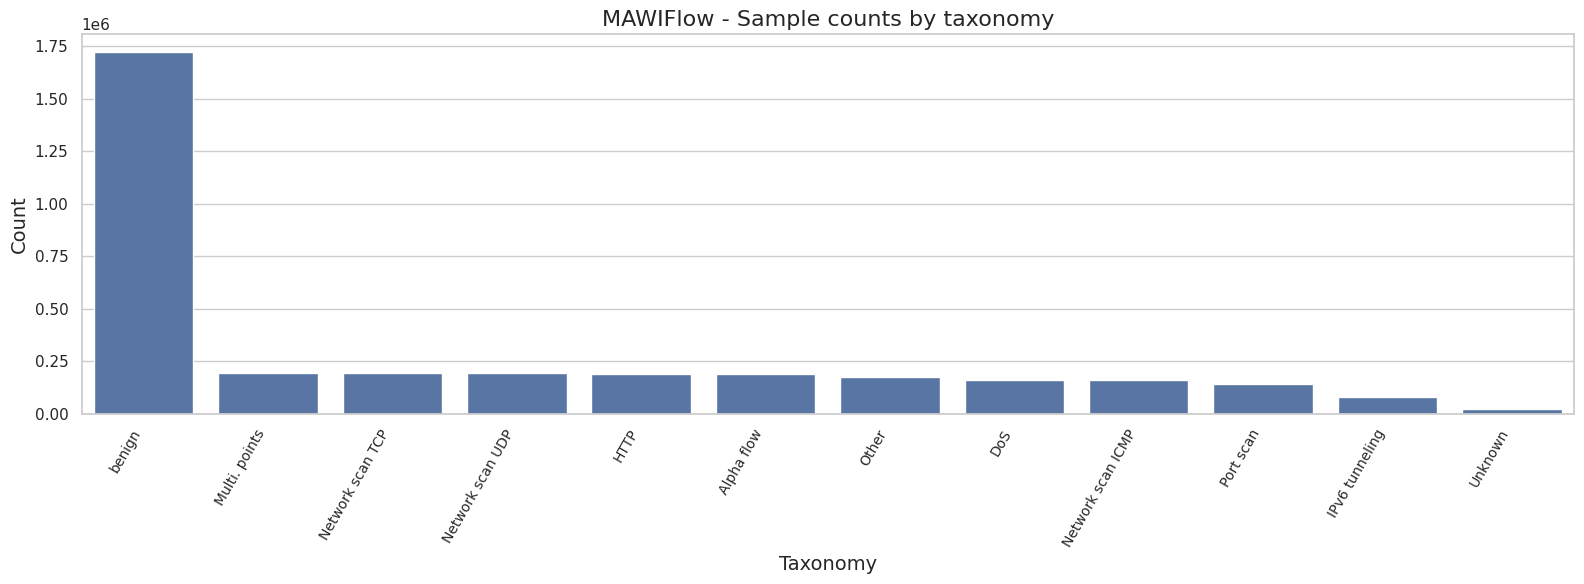

In [10]:
plt.figure(figsize=(16, 6))
sns.barplot(data=taxonomy_counts, x='taxonomy_norm', y='count')

plt.xticks(rotation=60, ha='right', fontsize=10)
plt.title('MAWIFlow - Sample counts by taxonomy', fontsize=16)
plt.xlabel('Taxonomy', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
taxonomy_monthly = (
    samples
    .group_by(['year', 'month', 'taxonomy_norm'])
    .agg(pl.len())
    .with_columns([
        pl.date(
            year=pl.col('year').cast(pl.Int32),
            month=pl.col('month').cast(pl.Int32),
            day=1
        ),
        pl.col('len').alias('count')
    ])
    .select(['date', 'taxonomy_norm', 'count'])
    .sort(['date', 'taxonomy_norm'])
    .to_pandas()
    .pivot(index='date', columns='taxonomy_norm', values='count')
)

In [12]:
taxonomy_monthly.head()

taxonomy_norm,Alpha flow,DoS,HTTP,IPv6 tunneling,Multi. points,Network scan ICMP,Network scan TCP,Network scan UDP,Other,Port scan,Unknown,benign
date,,,,,,,,,,,,
2007-01-01,1000.0,1000.0,1000.0,34.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,NaN,9034.0
2007-02-01,1000.0,1000.0,1000.0,435.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,NaN,9435.0
2007-03-01,1000.0,1000.0,1000.0,338.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,NaN,9338.0
2007-04-01,1000.0,1000.0,1000.0,111.0,1000.0,1000.0,1000.0,1000.0,1000.0,136.0,8.0,8255.0
2007-05-01,1000.0,1000.0,1000.0,202.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,NaN,9202.0


In [13]:
taxonomy_monthly_splits = (
    samples
    .group_by(['split', 'year', 'month', 'taxonomy_norm'])
    .agg(pl.len())
    .with_columns([
        pl.date(
            year=pl.col('year').cast(pl.Int32),
            month=pl.col('month').cast(pl.Int32),
            day=1
        ),
        pl.col('len').alias('count')
    ])
    .select(['split', 'date', 'taxonomy_norm', 'count'])
    .sort(['date', 'taxonomy_norm', 'split'])
    .to_pandas()
)

In [14]:
taxonomy_monthly_splits.pivot(
    index='date',
    columns=['taxonomy_norm', 'split'],
    values='count'
).fillna(0).astype(int)

taxonomy_norm Alpha flow              DoS             HTTP              \
split               test train valid test train valid test train valid   
date                                                                     
2007-01-01           200   600   200  200   600   200  200   600   200   
2007-02-01           200   600   200  200   600   200  200   600   200   
2007-03-01           200   600   200  200   600   200  200   600   200   
2007-04-01           200   600   200  200   600   200  200   600   200   
2007-05-01           200   600   200  200   600   200  200   600   200   
2007-06-01           200   600   200  200   600   200  200   600   200   
2007-07-01           200   600   200    0     0     0  200   600   200   
2007-08-01           200   600   200  200   600   200  200   600   200   
2007-09-01           200   600   200  200   600   200  200   600   200   
2007-10-01           200   600   200  200   600   200  200   600   200   
2007-11-01           200   600   200  200   600   200  200   600   200   
2007-12-01           200   600   200   96   287    96  200   600   200   
2008-01-01           200   600   200  200   600   200  200   600   200   
2008-02-01           200   600   200  146   436   146  200   600   200   
2008-03-01           200   600   200  200   600   200  200   600   200   
2008-04-01           200   600   200  200   600   200  200   600   200   
2008-05-01           200   600   200  200   600   200  200   600   200   
2008-06-01           200   600   200  200   600   200  200   600   200   
2008-07-01           200   600   200  200   600   200  200   600   200   
2008-08-01           200   600   200  200   600   200  200   600   200   
2008-09-01           200   600   200  200   600   200  200   600   200   
2008-10-01           200   600   200  200   600   200  200   600   200   
2008-11-01           200   600   200  200   600   200  200   600   200   
2008-12-01           200   600   200  200   600   200  200   600   200   
2009-01-01           200   600   200  200   600   200  200   600   200   
2009-02-01           200   600   200  200   600   200  200   600   200   
2009-03-01           200   600   200  200   600   200  200   600   200   
2009-04-01           200   600   200  200   600   200  200   600   200   
2009-05-01           200   600   200  200   600   200  200   600   200   
2009-06-01           184   550   183  200   600   200  200   600   200   
2009-07-01           200   600   200   55   163    54  200   600   200   
2009-08-01           200   600   200    8    22     8  200   600   200   
2009-09-01           200   600   200  200   600   200  200   600   200   
2009-10-01           200   600   200  200   600   200  200   600   200   
2009-11-01           200   600   200  200   600   200  200   600   200   
2009-12-01           200   600   200  200   600   200  200   600   200   
2010-01-01           200   600   200  200   600   200  200   600   200   
2010-02-01           200   600   200  200   600   200  200   600   200   
2010-03-01           200   600   200    0     0     0  200   600   200   
2010-04-01           200   600   200   18    52    17  200   600   200   
2010-05-01           200   600   200  200   600   200  200   600   200   
2010-06-01           200   600   200  200   600   200  200   600   200   
2010-07-01           200   600   200  200   600   200  200   600   200   
2010-08-01           200   600   200  200   600   200  200   600   200   
2010-09-01           200   600   200  200   600   200  200   600   200   
2010-10-01           200   600   200  200   600   200  200   600   200   
2010-11-01           200   600   200  200   600   200  200   600   200   
2010-12-01           200   600   200  200   600   200  200   600   200   
2011-01-01           200   600   200  200   600   200  200   600   200   
2011-02-01           200   600   200   44   130    43  200   600   200   
2011-03-01           200   600   200    0     0     0  200   600   200   
2011

In [15]:
(
    samples
    .group_by(['split', 'year', 'taxonomy_norm'])
    .agg(pl.len())
    .with_columns(pl.col('len').alias('count'))
    .select(['split', 'year', 'taxonomy_norm', 'count'])
    .sort(['year', 'taxonomy_norm', 'split'])
    .to_pandas()
    .pivot(index='year', columns=['taxonomy_norm', 'split'], values='count')
    .fillna(0)
    .astype(int)
)

taxonomy_norm Alpha flow               DoS              HTTP              \
split               test train valid  test train valid  test train valid   
year                                                                       
2007                2400  7200  2400  2096  6287  2096  2400  7200  2400   
2008                2400  7200  2400  2346  7036  2346  2400  7200  2400   
2009                2384  7150  2383  2063  6185  2062  2400  7200  2400   
2010                2400  7200  2400  2018  6052  2017  2400  7200  2400   
2011                2400  7200  2400  2044  6130  2043  2400  7200  2400   
2012                2400  7200  2400  2200  6600  2200  2400  7200  2400   
2013                2400  7200  2400  1725  5169  1723  2400  7200  2400   
2014                2400  7200  2400  2400  7200  2400  2400  7200  2400   
2015                2400  7200  2400  2400  7200  2400  2400  7200  2400   
2016                2400  7200  2400  2400  7200  2400  2400  7200  2400   
2017                2023  6066  2022   979  2920   973  2200  6600  2200   
2018                2251  6751  2251  1736  5200  1733  2400  7200  2400   
2019                2400  7200  2400  2001  6001  2001  2400  7200  2400   
2020                2400  7200  2400  2051  6152  2051  2400  7200  2400   
2021                2400  7200  2400  1850  5548  1849  2400  7200  2400   
2022                 200   600   200   200   600   200   200   600   200   
2023                1540  4618  1539  1487  4460  1487  1600  4800  1600   
2024                1107  3318  1107   776  2324   774   741  2212   737   

taxonomy_norm IPv6 tunneling             Multi. points              \
split                   test train valid          test train valid   
year                                                                 
2007                     526  1562   522          2400  7200  2400   
2008                     581  1721   575          2400  7200  2400   
2009                    1493  4467  1489          2400  7200  2400   
2010                    2400  7200  2400          2400  7200  2400   
2011                    2400  7200  2400          2400  7200  2400   
2012                    1847  5537  1847          2400  7200  2400   
2013                     138   392   132          2400  7200  2400   
2014                     392  1158   387          2400  7200  2400   
2015                     637  1897   634          2400  7200  2400   
2016                     734  2181   728          2400  7200  2400   
2017                     388  1150   385          2200  6600  2200   
2018                     542  1610   538          2400  7200  2400   
2019                     897  2678   896          2400  7200  2400   
2020                    1116  3327  1110          2400  7200  2400   
2021                    1088  3244  1081          2400  7200  2400   
2022                      22    64    22           200   600   200   
2023                    1352  4051  1350          1600  4800  1600   
2024                      58   171    58          1600  4800  1600   

taxonomy_norm Network scan ICMP             Network scan TCP              \
split                      test train valid             test train valid   
year                                                                       
2007                       2400  7200  2400             2400  7200  2400   
2008                       2400  7200  2400             2400  7200  2400   
2009                       2400  7200  2400             2400  7200  2400   
2010                       2264  6791  2264             2400  7200  2400   
2011                       1699  5090  1696             2400  7200  2400   
2012                       2400  7200  2400             2400  7200  2400   
2013                       1600  4800  1600             2400  7200  2400   
2014                        451  1352   451             2400  7200  2400   
2015                        982  2941   981             2400  7200  2400   
2016                

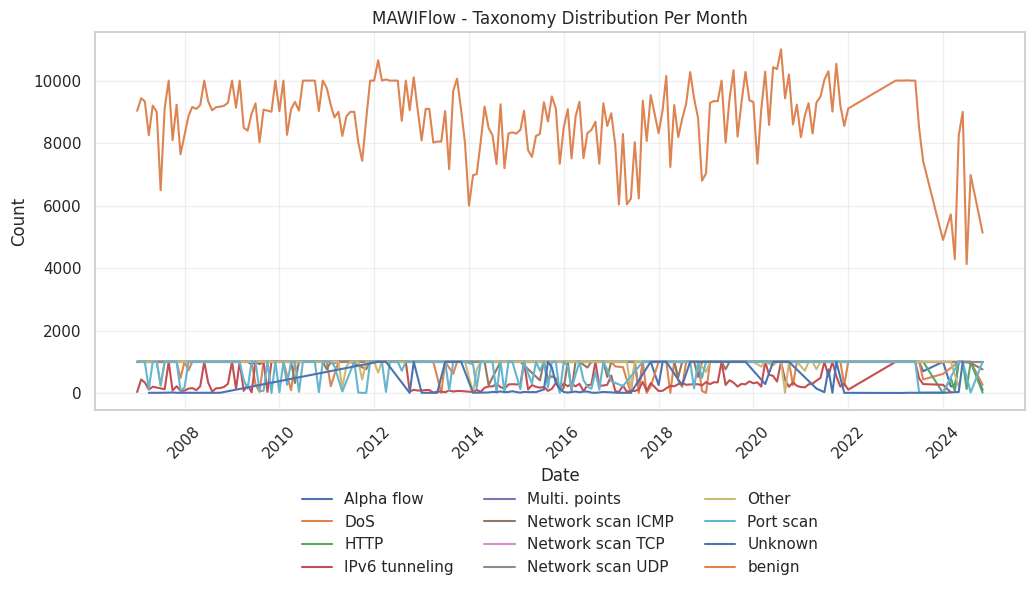

In [16]:
plt.figure(figsize=(12, 6))
for column in taxonomy_monthly.columns:
    sns.lineplot(
        x=taxonomy_monthly.index,
        y=taxonomy_monthly[column],
        label=column
    )

plt.title("MAWIFlow - Taxonomy Distribution Per Month")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),  # center, below the axes
    ncol=3,                       # spread items across columns
    frameon=False
)
plt.subplots_adjust(bottom=0.25)  # make room for the legend
plt.show()

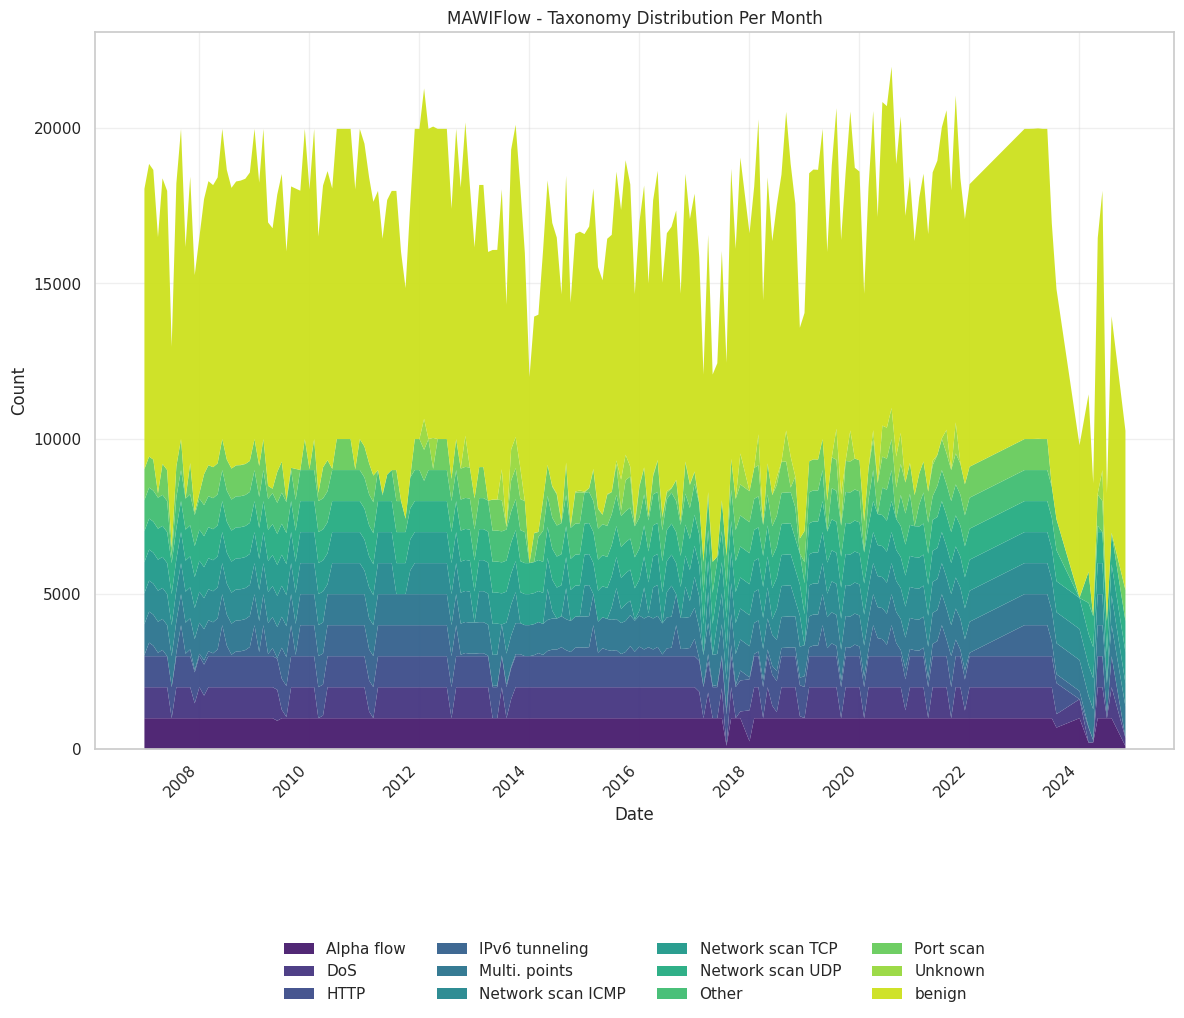

In [17]:
plt.figure(figsize=(12, 10))
tax_cols = list(taxonomy_monthly.columns)
tax_palette = sns.color_palette("viridis", n_colors=len(tax_cols))
taxonomy_monthly[tax_cols].fillna(0).plot.area(
    stacked=True,
    color=tax_palette,
    linewidth=0.0,
    ax=plt.gca(),
    alpha=0.95
)
plt.title("MAWIFlow - Taxonomy Distribution Per Month")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)
plt.subplots_adjust(bottom=0.30)
plt.tight_layout()
plt.show()

In [18]:
taxonomy_monthly_rel = taxonomy_monthly.div(taxonomy_monthly.sum(axis=1), axis=0).drop(columns=['benign'])

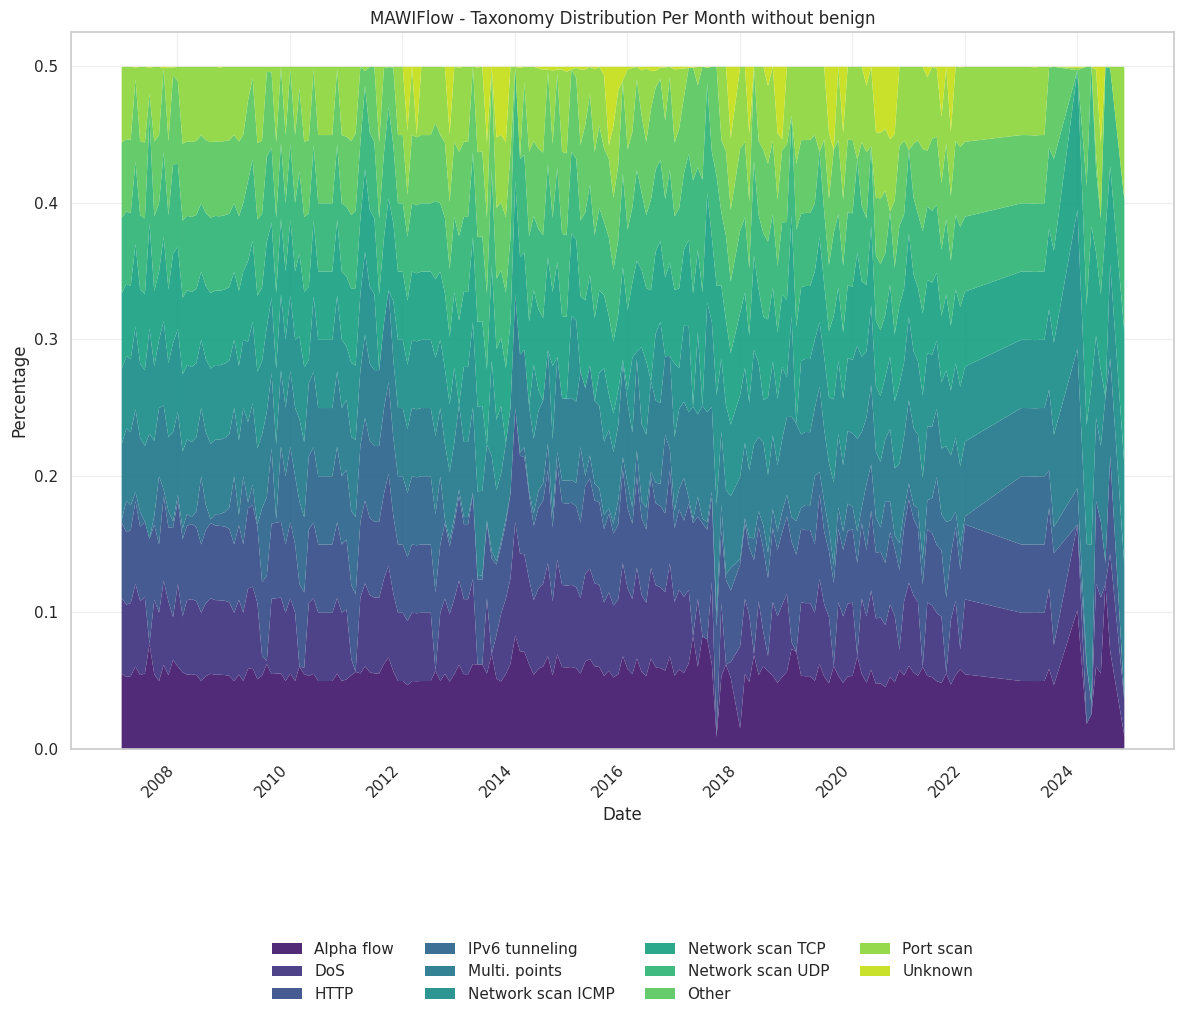

In [19]:
plt.figure(figsize=(12, 10))
tax_cols = list(taxonomy_monthly_rel.columns)
tax_palette = sns.color_palette("viridis", n_colors=len(tax_cols))
taxonomy_monthly_rel[tax_cols].fillna(0).plot.area(
    stacked=True,
    color=tax_palette,
    linewidth=0.0,
    ax=plt.gca(),
    alpha=0.95
)
plt.title("MAWIFlow - Taxonomy Distribution Per Month without benign")
plt.xlabel("Date")
plt.ylabel("Percentage")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)
plt.subplots_adjust(bottom=0.30)
plt.tight_layout()
plt.show()

In [20]:
features = [
    "Flow Duration",
    "Total Fwd Packet",
    "Total Bwd packets",
    "Total Length of Fwd Packet",
    "Total Length of Bwd Packet",
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Fwd Packet Length Std",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Bwd Packet Length Mean",
    "Bwd Packet Length Std",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Total",
    "Fwd IAT Mean",
    "Fwd IAT Std",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Bwd IAT Total",
    "Bwd IAT Mean",
    "Bwd IAT Std",
    "Bwd IAT Max",
    "Bwd IAT Min",
    "Fwd PSH Flags",
    "Bwd PSH Flags",
    "Fwd URG Flags",
    "Bwd URG Flags",
    "Fwd RST Flags",
    "Bwd RST Flags",
    "Fwd Header Length",
    "Bwd Header Length",
    "Fwd Packets/s",
    "Bwd Packets/s",
    "Packet Length Min",
    "Packet Length Max",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance",
    "FIN Flag Count",
    "SYN Flag Count",
    "RST Flag Count",
    "PSH Flag Count",
    "ACK Flag Count",
    "URG Flag Count",
    "CWR Flag Count",
    "ECE Flag Count",
    "Down/Up Ratio",
    "Average Packet Size",
    "Fwd Segment Size Avg",
    "Bwd Segment Size Avg",
    "Fwd Bytes/Bulk Avg",
    "Fwd Packet/Bulk Avg",
    "Fwd Bulk Rate Avg",
    "Bwd Bytes/Bulk Avg",
    "Bwd Packet/Bulk Avg",
    "Bwd Bulk Rate Avg",
    "Subflow Fwd Packets",
    "Subflow Fwd Bytes",
    "Subflow Bwd Packets",
    "Subflow Bwd Bytes",
    "FWD Init Win Bytes",
    "Bwd Init Win Bytes",
    "Fwd Act Data Pkts",
    "Bwd Act Data Pkts",
    "Fwd Seg Size Min",
    "Bwd Seg Size Min",
    "Active Mean",
    "Active Std",
    "Active Max",
    "Active Min",
    "Idle Mean",
    "Idle Std",
    "Idle Max",
    "Idle Min",
    "ICMP Code",
    "ICMP Type",
    "Fwd TCP Retrans. Count",
    "Bwd TCP Retrans. Count",
    "Total TCP Retrans. Count",
    "Total Connection Flow Time",
]

In [21]:
# One-cell PCA-by-year for a Polars DataFrame
# - Standardizes features per year (no leakage)
# - Computes per-feature variance (pre-standardization) per year
# - Runs PCA per year and returns explained variance ratios and loadings
# Usage (at bottom): res = pca_by_year(df, year_col="year", exclude=["label"], sample_per_year=100_000, n_components=20)

def pca_by_year(
    df: pl.DataFrame,
    year_col: str = "year",
    exclude: Optional[Iterable[str]] = None,
    sample_per_year: Optional[int] = None,
    n_components: Optional[int] = None,
    drop_nulls: bool = True,
    seed: int = 42,
) -> Dict[str, pl.DataFrame]:
    """
    Run PCA on numeric features per year.
    Returns dict with:
      - feature_variance_by_year: long table [year, feature, variance]
      - explained_variance_ratio_by_year: wide table [year, pc1..pcK]
      - loadings_by_year: long table [year, feature, pc, loading]
    """
    if year_col not in df.columns:
        raise ValueError(f"year_col='{year_col}' not in DataFrame.")

    excl = set(exclude or [])
    # Determine numeric feature columns (exclude year + any listed columns)
    numeric_cols = [
        c for c, dt in zip(df.columns, df.dtypes)
        if (dt.is_numeric() and c != year_col and c not in excl)
    ]
    if not numeric_cols:
        raise ValueError("No numeric feature columns found after exclusions.")

    # Ensure year is integer-like for sorting/joins
    years = sorted(pl.Series(df[year_col]).cast(pl.Int64).unique().to_list())

    var_rows = []
    evr_rows = []
    load_rows = []

    rng = np.random.default_rng(seed)

    for y in years:
        dfy = df.filter(pl.col(year_col) == y).select([year_col] + numeric_cols)
        if drop_nulls:
            dfy = dfy.drop_nulls()
        else:
            dfy = dfy.fill_null(0)

        if dfy.height == 0:
            continue

        # Optional downsample (row-wise) to bound PCA cost
        feats = dfy.select(numeric_cols)
        if sample_per_year is not None and feats.height > sample_per_year:
            # Use numpy choice on row indices for speed
            idx = rng.choice(feats.height, size=sample_per_year, replace=False)
            feats = feats.take(idx.tolist())

        if feats.height < 2 or len(numeric_cols) < 2:
            continue

        X = feats.to_numpy()

        # 1) Per-feature variance BEFORE standardization (drift signal)
        v = feats.select([pl.col(c).var().alias(c) for c in numeric_cols])
        v = v.with_columns(pl.lit(int(y)).alias(year_col))
        var_rows.append(v)

        # 2) PCA on standardized data
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)
        k = min(
            n_components if n_components is not None else Xs.shape[1],
            Xs.shape[1],
            Xs.shape[0]
        )
        pca = PCA(n_components=k, svd_solver="auto", random_state=seed)
        pca.fit(Xs)

        # 2a) Explained variance ratio (wide)
        evr_dict = {f"pc{i+1}": float(pca.explained_variance_ratio_[i]) for i in range(k)}
        evr_dict[year_col] = int(y)
        evr_rows.append(evr_dict)

        # 2b) Loadings (long): component vectors per feature
        comps = pca.components_  # shape [k, n_features]
        # Build long table for this year
        load_rows.append(
            pl.DataFrame({
                "year": [int(y)] * (k * len(numeric_cols)),
                "feature": sum([[f]*k for f in numeric_cols], []),
                "pc": [i+1 for _ in numeric_cols for i in range(k)],
                "loading": comps.T.reshape(-1).tolist(),
            })
        )

    # Assemble outputs
    feature_var = pl.concat(var_rows, how="vertical") if var_rows else pl.DataFrame()
    if feature_var.height > 0:
        feature_var = feature_var.unpivot(
            index=[year_col],
            on=None,  # all columns except index
            variable_name="feature",
            value_name="variance"
        )

    if evr_rows:
        # Normalize to same number of PCs across years (pad with NaN)
        max_k = max(len(d) - 1 for d in evr_rows)
        for d in evr_rows:
            for i in range(1, max_k + 1):
                d.setdefault(f"pc{i}", np.nan)
        explained = pl.DataFrame(evr_rows).select(
            [year_col] + [f"pc{i}" for i in range(1, max_k + 1)]
        ).sort(year_col)
    else:
        explained = pl.DataFrame()

    loadings = pl.concat(load_rows, how="vertical") if load_rows else pl.DataFrame()

    return {
        "feature_variance_by_year": feature_var,
        "explained_variance_ratio_by_year": explained,
        "loadings_by_year": loadings,
    }

In [22]:
res = pca_by_year(
    samples.select(features + ['year']),
    year_col="year",
)

In [23]:
# PCs needed to hit a target variance per year
def plot_pcs_for_target(res, target=0.95):
    evr = res["explained_variance_ratio_by_year"]
    if evr.is_empty():
        print("No EVR data.")
        return
    evr_pd = evr.to_pandas().set_index("year").sort_index()
    cum = evr_pd.apply(np.cumsum, axis=1)
    pcs_needed = cum.apply(lambda row: np.searchsorted(row.values, target) + 1, axis=1)
    df = pcs_needed.reset_index()
    df.columns = ["year", "pcs_needed"]

    plt.figure(figsize=(7, 4))
    ax = sns.lineplot(data=df, x="year", y="pcs_needed", marker="o")
    ax.axhline(df["pcs_needed"].mean(), linestyle="--")
    ax.set_title(f"PCs needed to reach {int(target*100)}% variance")
    ax.set_xlabel("Year"); ax.set_ylabel("#PCs")
    plt.tight_layout()

In [24]:
# Heatmap of per-feature raw variance over years (log scale)
def plot_feature_variance_heatmap(res, top_n_features=40):
    fv = res["feature_variance_by_year"]
    if fv.is_empty():
        print("No per-feature variance data.")
        return
    fv_pd = fv.to_pandas()
    M = fv_pd.pivot(index="year", columns="feature", values="variance").sort_index()
    keep = M.var().sort_values(ascending=False).head(top_n_features).index
    M = M[keep].clip(lower=1e-12)  # avoid log(0)

    plt.figure(figsize=(min(12, 0.25*len(keep)+4), max(4, 0.35*len(M.index))))
    ax = sns.heatmap(np.log10(M), cbar_kws={"label": "log10(variance)"})
    ax.set_title("Per-feature variance by year (top features)")
    ax.set_xlabel("Feature"); ax.set_ylabel("Year")
    plt.xticks(rotation=90)
    plt.tight_layout()

In [25]:
# Bar chart: top-|loading| features for a given PC and year
def plot_top_loadings(res, year, pc=1, top_k=20):
    L = res["loadings_by_year"]
    if L.is_empty():
        print("No loadings data.")
        return
    sel = (L.filter((pl.col("year")==year) & (pl.col("pc")==pc))
             .with_columns(pl.col("loading").abs().alias("abs_loading"))
             .sort("abs_loading", descending=True)
             .head(top_k)
             .select("feature","loading","abs_loading"))
    if sel.is_empty():
        print(f"No loadings for year={year}, pc={pc}.")
        return
    s = sel.to_pandas().sort_values("abs_loading")

    plt.figure(figsize=(8, max(4, 0.35*len(s))))
    ax = sns.barplot(data=s, x="loading", y="feature", orient="h")
    ax.set_title(f"Top |loadings| — Year {year}, PC{pc}")
    ax.set_xlabel("Loading"); ax.set_ylabel("Feature")
    plt.tight_layout()

In [26]:
# PC drift: cosine similarity of PC1 loadings across years
def plot_pc_similarity_heatmap(res, pc=1):
    L = res["loadings_by_year"]
    if L.is_empty():
        print("No loadings data.")
        return
    Lp = L.filter(pl.col("pc")==pc).to_pandas()
    if Lp.empty:
        print(f"No loadings for PC{pc}.")
        return
    W = Lp.pivot_table(index="feature", columns="year", values="loading").fillna(0.0)
    A = W.values  # features × years
    norms = np.linalg.norm(A, axis=0, keepdims=True); norms[norms==0] = 1.0
    S = (A.T @ A) / (norms.T @ norms)  # cosine similarity
    years = W.columns.to_numpy()

    plt.figure(figsize=(6.5, 5.5))
    ax = sns.heatmap(S, vmin=-1, vmax=1, square=True, center=0,
                     xticklabels=years, yticklabels=years,
                     cbar_kws={"label": "Cosine similarity"})
    ax.set_title(f"PC{pc} loading similarity across years")
    ax.set_xlabel("Year"); ax.set_ylabel("Year")
    plt.tight_layout()

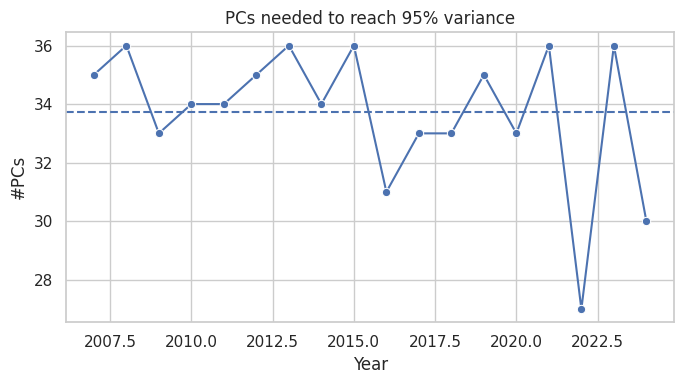

In [27]:
plot_pcs_for_target(res, target=0.95)

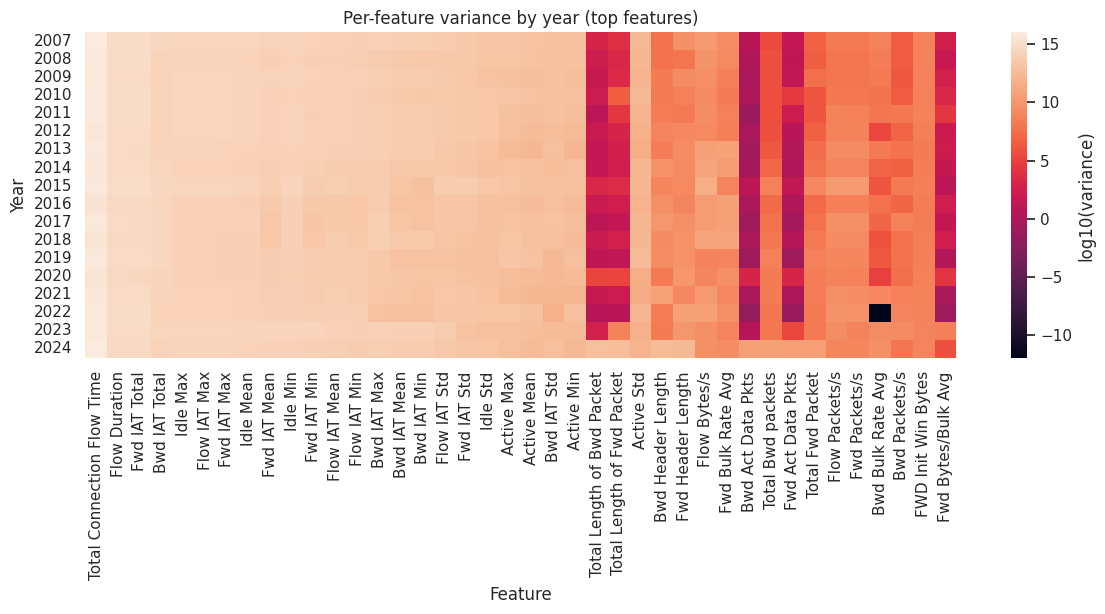

In [28]:
plot_feature_variance_heatmap(res, top_n_features=40)

In [29]:
# plot_pc_similarity_heatmap(res, pc=1)

In [30]:
# mptplaHTTP_flows = samples.filter(pl.col("taxonomy_norm") == "mptplaHTTP").to_pandas()

# plt.figure(figsize=(10, 7))
# sns.boxplot(
#     data=mptplaHTTP_flows,
#     x="year",
#     y="Flow Duration"
# )
# plt.title('Flow Duration Boxplot per Year (taxonomy_norm == "mptplaHTTP")')
# plt.xlabel("Year")
# plt.ylabel("Flow Duration")
# plt.tight_layout()
# plt.show()